Optimization Status: Optimal
Total Annual Cost: $1,150,263.00


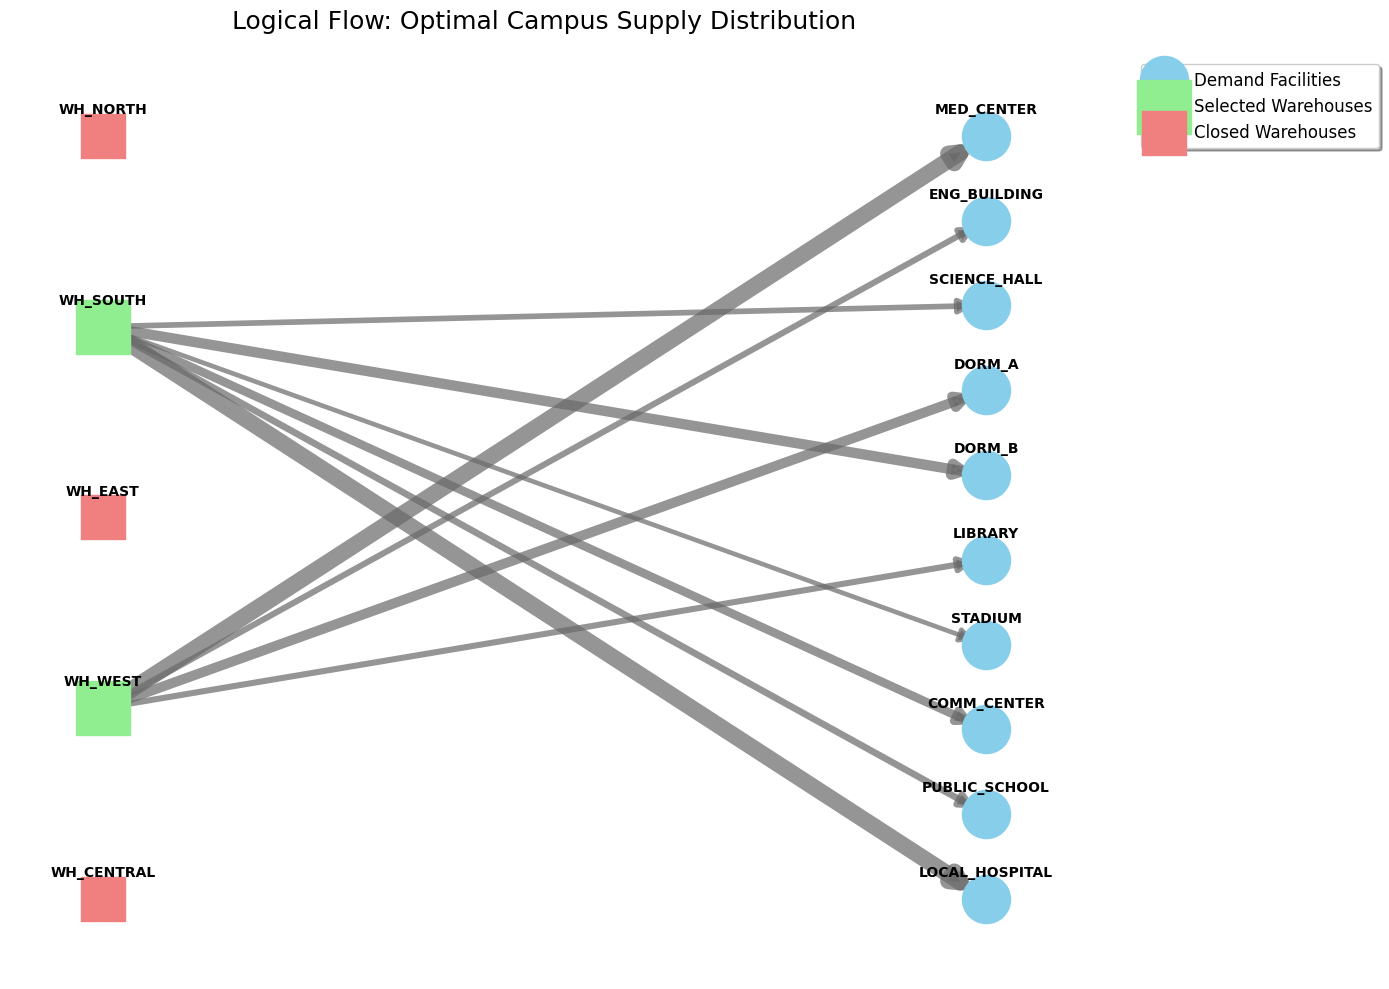

In [7]:
import pandas as pd
import pulp
import matplotlib.pyplot as plt
import networkx as nx

# --- 1. Load Data from CSV Files ---
data_dir = '../data/'

demands = pd.read_csv(f'{data_dir}demands.csv')
facilities = pd.read_csv(f'{data_dir}facilities.csv')
warehouses = pd.read_csv(f'{data_dir}warehouses.csv')
trans_costs = pd.read_csv(f'{data_dir}transportation_costs.csv')

facilities = pd.merge(facilities, demands, on='facility_id')

# --- 2. Annualize Costs, Demands, and Capacities ---
facilities['annual_demand'] = facilities['daily_demand'] * 365
warehouses['annual_capacity'] = warehouses['capacity'] * 365
warehouses['annual_fixed_cost'] = (warehouses['construction_cost'] / 10) + (warehouses['operational_cost'] * 365)

annual_demand = dict(zip(facilities['facility_id'], facilities['annual_demand']))
annual_capacity = dict(zip(warehouses['warehouse_id'], warehouses['annual_capacity']))
annual_fixed_cost = dict(zip(warehouses['warehouse_id'], warehouses['annual_fixed_cost']))

cost_per_unit = {(row['from_warehouse'], row['to_facility']): row['cost_per_unit'] for _, row in trans_costs.iterrows()}

wh_list = warehouses['warehouse_id'].tolist()
fac_list = facilities['facility_id'].tolist()

# --- 3. Initialize and Solve the MILP Model ---
model = pulp.LpProblem("Campus_Distribution_Network", pulp.LpMinimize)

y = pulp.LpVariable.dicts("Open_Warehouse", wh_list, cat='Binary')
x = pulp.LpVariable.dicts("Shipment", [(w, f) for w in wh_list for f in fac_list], lowBound=0, cat='Continuous')

total_fixed = pulp.lpSum(annual_fixed_cost[w] * y[w] for w in wh_list)
total_trans = pulp.lpSum(x[(w, f)] * cost_per_unit.get((w, f), 999999) for w in wh_list for f in fac_list)
model += total_fixed + total_trans, "Total_Annual_Cost"

model += pulp.lpSum(y[w] for w in wh_list) == 2, "Select_2_Warehouses"
for f in fac_list:
    model += pulp.lpSum(x[(w, f)] for w in wh_list) == annual_demand[f], f"Demand_Satisfaction_{f}"
for w in wh_list:
    model += pulp.lpSum(x[(w, f)] for f in fac_list) <= annual_capacity[w] * y[w], f"Capacity_Limit_{w}"
model += total_fixed + total_trans <= 1500000, "Budget_Limit"

model.solve()
print(f"Optimization Status: {pulp.LpStatus[model.status]}")
print(f"Total Annual Cost: ${pulp.value(model.objective):,.2f}")

# --- 4. Visual Representation (Clean Bipartite Flow) ---
fig, ax = plt.subplots(figsize=(14, 10))

# Create a clean, perfectly spaced layout (Warehouses left, Facilities right)
pos = {}
# Space warehouses evenly on the left (x = 0)
y_space_wh = 10 / max(1, len(wh_list) - 1)
for i, w in enumerate(wh_list):
    pos[w] = (0, 10 - i * y_space_wh)

# Space facilities evenly on the right (x = 1)
y_space_fac = 10 / max(1, len(fac_list) - 1)
for i, f in enumerate(fac_list):
    pos[f] = (1, 10 - i * y_space_fac)

open_wh = [w for w in wh_list if y[w].varValue == 1.0]
closed_wh = [w for w in wh_list if y[w].varValue == 0.0]

# --- Network Graph ---
G = nx.DiGraph()
G.add_nodes_from(fac_list + wh_list)

edges = []
edge_weights = []
for w in open_wh:
    for f in fac_list:
        shipped = x[(w, f)].varValue
        if shipped and shipped > 0:
            G.add_edge(w, f, weight=shipped)
            edges.append((w, f))
            edge_weights.append(shipped / 2500) # Adjusted thickness scale for clarity

# Draw Nodes
nx.draw_networkx_nodes(G, pos, nodelist=fac_list, node_color='skyblue', node_shape='o', node_size=1200, ax=ax, label='Demand Facilities')
nx.draw_networkx_nodes(G, pos, nodelist=open_wh, node_color='lightgreen', node_shape='s', node_size=1500, ax=ax, label='Selected Warehouses')
nx.draw_networkx_nodes(G, pos, nodelist=closed_wh, node_color='lightcoral', node_shape='s', node_size=1000, ax=ax, label='Closed Warehouses')

# Draw Edges (Straight, clean lines since there's no overlap in this layout)
nx.draw_networkx_edges(G, pos, edgelist=edges, arrowstyle='-|>', arrowsize=20, 
                       edge_color='dimgray', width=edge_weights, alpha=0.7, ax=ax)

# Draw Labels (Pushed slightly up and perfectly centered)
label_pos = {k: (v[0], v[1] + 0.35) for k, v in pos.items()} 
nx.draw_networkx_labels(G, label_pos, font_size=10, font_weight='bold', ax=ax)

# --- Final Plot Formatting ---
plt.title('Logical Flow: Optimal Campus Supply Distribution', fontsize=18, pad=20)

# Turn off the axis grid completely for a clean look
plt.axis('off')

# Move Legend Outside
plt.legend(scatterpoints=1, loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=12, frameon=True, shadow=True)

plt.tight_layout()
plt.savefig('distribution_network_flow.png', dpi=300, bbox_inches='tight')
plt.show()